# Credit Scoring — Exploratory Data Analysis

## Project objective

The goal of this project is to develop a machine learning model
for credit risk assessment.

## 1. Imports & configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

## 2. Data loading


In [5]:
df = pd.read_csv('data/train.csv', index_col='Id')
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Id,,,,,,,,,,,
1,0,0.957,40,0,0.122,2600.000,4,0,0,0,1.000
2,0,0.658,38,1,0.085,3042.000,2,1,0,0,0.000
3,0,0.234,30,0,0.036,3300.000,5,0,0,0,0.000
4,0,0.907,49,1,0.025,63588.000,7,0,1,0,0.000
5,0,0.213,74,0,0.376,3500.000,3,0,1,0,1.000


In [6]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (104805, 11)


## 3. Dataset overview

In [8]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 104,805
Columns: 11


In [9]:
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 104805 entries, 1 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      104805 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 2   age                                   104805 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 4   DebtRatio                             104805 non-null  float64
 5   MonthlyIncome                         84024 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 7   NumberOfTimes90DaysLate               104805 non-null  int64  
 8   NumberRealEstateLoansOrLines          104805 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  int64  
 10  NumberOfDependents                    102056 non-null  float64
dtypes: float64(4), i

In [11]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"]
    / len(df)
    * 100
)

missing = missing.sort_values(
    "missing_percent",
    ascending=False
)

missing

,missing_count,missing_percent
MonthlyIncome,20781,19.828
NumberOfDependents,2749,2.623
SeriousDlqin2yrs,0,0.000
age,0,0.000
RevolvingUtilizationOfUnsecuredLines,0,0.000
DebtRatio,0,0.000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000
NumberOfOpenCreditLinesAndLoans,0,0.000
NumberOfTimes90DaysLate,0,0.000
NumberRealEstateLoansOrLines,0,0.000


### Duplicate observations

In [12]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 353


### Conclusion

The dataset contains 353 duplicated feature rows.

These observations will not be removed at this stage.
We will investigate whether duplicated observations are associated
with different target values before making a preprocessing decision.

## 4. Target analysis

The target variable is `SeriousDlqin2yrs`.

- `0` — no serious delinquency within two years
- `1` — serious delinquency within two years

In [15]:
target_counts = df["SeriousDlqin2yrs"].value_counts()

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_counts / len(df) * 100
})

target_summary

,count,percentage
SeriousDlqin2yrs,,
0,97855,93.369
1,6950,6.631


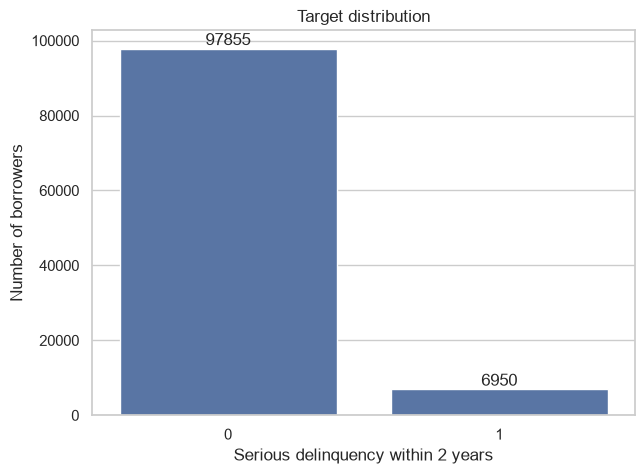

In [19]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="SeriousDlqin2yrs"
)

plt.title("Target distribution")
plt.xlabel("Serious delinquency within 2 years")
plt.ylabel("Number of borrowers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

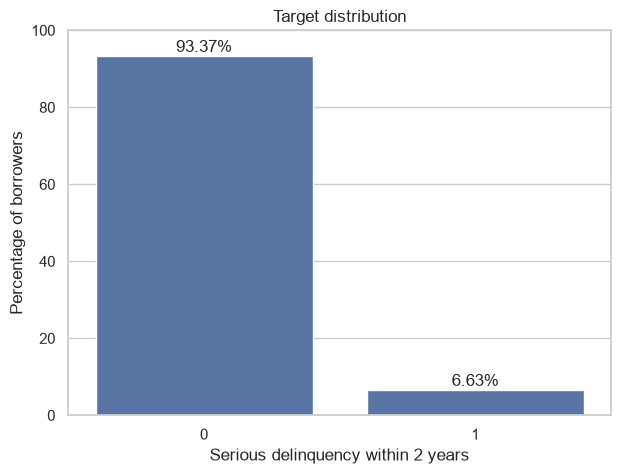

In [20]:
target_percent = (
    df["SeriousDlqin2yrs"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_percent.index,
    y=target_percent.values
)

plt.title("Target distribution")
plt.xlabel("Serious delinquency within 2 years")
plt.ylabel("Percentage of borrowers")

for i, value in enumerate(target_percent.values):
    ax.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.show()

### Conclusion

The target variable is strongly imbalanced.

Only approximately 6.63% of borrowers belong to the positive
class, while approximately 93.37% belong to the negative class.

Therefore, accuracy alone will not be an appropriate metric for
evaluating the final classification model.

ROC-AUC, PR-AUC, precision, recall and the confusion matrix will
be considered during model evaluation.

## 5. Feature analysis

In [22]:
continuous_features = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome"
]

In [23]:
count_features = [
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

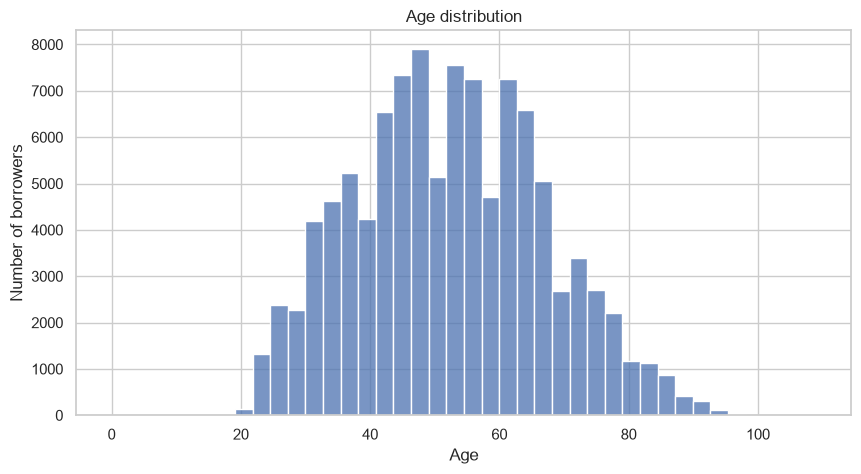

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="age",
    bins=40
)

plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Number of borrowers")

plt.show()

### Age distribution

The age distribution is concentrated around the middle-aged
borrower population. One observation has age 0, while 10
observations have age above 100.

The age value of 0 will be investigated as a potential data-quality
issue. Extreme ages above 100 will not be removed automatically.

## 6. Data quality investigation

### Suspicious delinquency values

In [27]:
late_payment_features = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

In [28]:
for feature in late_payment_features:
    count_98 = (df[feature] == 98).sum()

    print(f"{feature}: {count_98:,} observations with value 98")

NumberOfTime30-59DaysPastDueNotWorse: 181 observations with value 98
NumberOfTime60-89DaysPastDueNotWorse: 181 observations with value 98
NumberOfTimes90DaysLate: 181 observations with value 98


In [29]:
mask_98 = (
    df[late_payment_features]
    .eq(98)
    .all(axis=1)
)

target_rate = (
    df.assign(has_98=mask_98)
      .groupby("has_98")["SeriousDlqin2yrs"]
      .mean()
      * 100
)

target_rate

has_98
False    6.552
True    52.486
Name: SeriousDlqin2yrs, dtype: float64

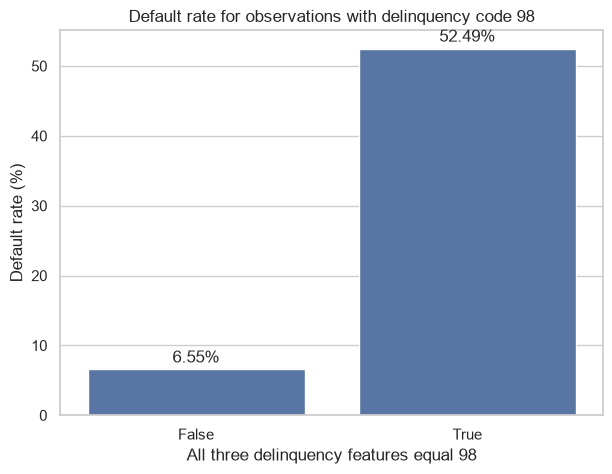

In [30]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_rate.index,
    y=target_rate.values
)

plt.title("Default rate for observations with delinquency code 98")
plt.xlabel("All three delinquency features equal 98")
plt.ylabel("Default rate (%)")

for i, value in enumerate(target_rate.values):
    ax.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()